In [1]:
import pandas as pd

# Replace with your actual file path
filepath = "COVID-19_Vaccinations_in_the_United_States_County_20250731.csv"
df = pd.read_csv(filepath, low_memory=False)

# Minimal columns for the presentation
needed = [
    "Date",
    "FIPS",
    "Recip_County",
    "Recip_State",
    "Metro_status",
    "Series_Complete_Pop_Pct",
    "Series_Complete_Pop_Pct_SVI",
    "Census2019",
    "Booster_Doses_Vax_Pct",  # optional
]

# Keep only those that exist to avoid errors
keep_cols = [c for c in needed if c in df.columns]
df_minimal = df[keep_cols].copy()

# Save filtered CSV for use
df_minimal.to_csv("vaccination_minimal_filtered.csv", index=False)

# Example disparity summary: average coverage by Metro_status
if "Metro_status" in df_minimal.columns and "Series_Complete_Pop_Pct" in df_minimal.columns:
    summary = df_minimal.groupby("Metro_status")["Series_Complete_Pop_Pct"].mean().reset_index()
    print("\nAverage completion % by Metro_status:\n", summary.to_string())



Average completion % by Metro_status:
   Metro_status  Series_Complete_Pop_Pct
0        Metro                38.406664
1    Non-metro                33.113192


In [2]:
# Ensure we have the most recent row per FIPS
df_latest = df_minimal.sort_values("Date").groupby("FIPS", as_index=False).last()

# Compute average coverage by Metro_status (urban/rural)
disparity = df_latest.groupby("Metro_status")["Series_Complete_Pop_Pct"].mean().reset_index()
print("Average Series Complete % by Metro_status:\n", disparity.to_string())

# Compute gap (assumes Metro_status has two main categories like 'metro' vs 'non-metro')
pivot = disparity.pivot_table(index=None, columns="Metro_status", values="Series_Complete_Pop_Pct")
# If names differ, adjust accordingly
print("\nCoverage gap (example):")
print(pivot)


Average Series Complete % by Metro_status:
   Metro_status  Series_Complete_Pop_Pct
0        Metro                52.469862
1    Non-metro                45.028737

Coverage gap (example):
Metro_status                 Metro  Non-metro
Series_Complete_Pop_Pct  52.469862  45.028737


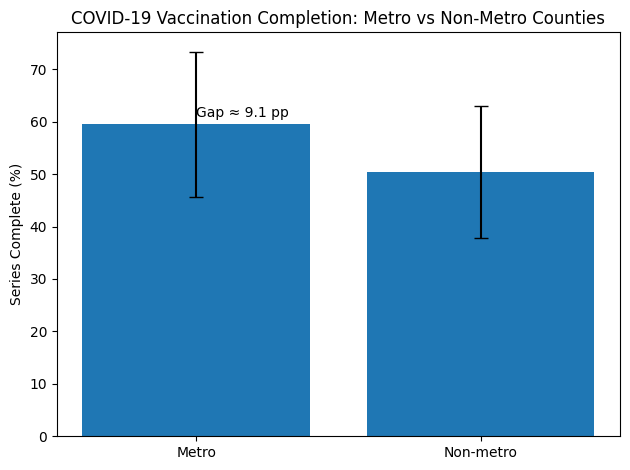

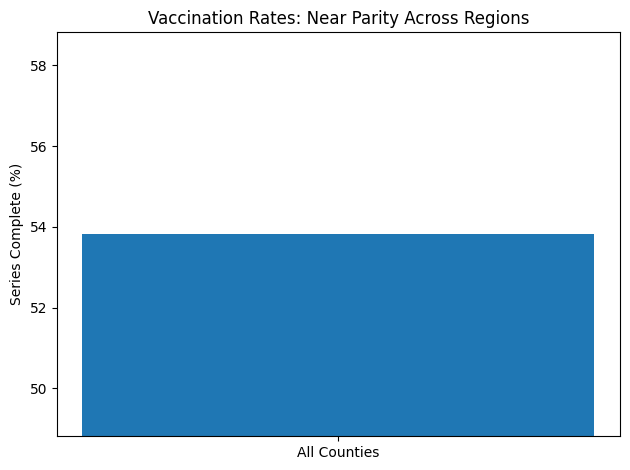

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# load filtered already-prepped data
df = pd.read_csv("vaccination_minimal_filtered.csv", low_memory=False)
df["Date_parsed"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df_latest = df.sort_values("Date_parsed").groupby("FIPS", as_index=False).last()

# compute group means
disparity = df_latest.groupby("Metro_status")["Series_Complete_Pop_Pct"].agg(["mean", "std"]).reset_index()
metro = disparity.loc[disparity["Metro_status"] == "Metro", "mean"].values[0]
nonmetro = disparity.loc[disparity["Metro_status"] == "Non-metro", "mean"].values[0]
gap = metro - nonmetro
overall = df_latest["Series_Complete_Pop_Pct"].mean()

# White hat plot (with error bars)
plt.figure()
plt.bar(disparity["Metro_status"], disparity["mean"], yerr=disparity["std"], capsize=5)
plt.ylabel("Series Complete (%)")
plt.title("COVID-19 Vaccination Completion: Metro vs Non-Metro Counties")
plt.annotate(f"Gap ≈ {gap:.1f} pp", xy=("Metro", metro), xytext=(0, 5), textcoords="offset points")
plt.tight_layout()
plt.savefig("white_hat.png")  # for screenshot
plt.show()

# Black hat plot (aggregated, truncated axis)
plt.figure()
plt.bar(["All Counties"], [overall])
plt.ylim(overall - 5, overall + 5)  # compress visually
plt.ylabel("Series Complete (%)")
plt.title("Vaccination Rates: Near Parity Across Regions")
plt.tight_layout()
plt.savefig("black_hat.png")
plt.show()


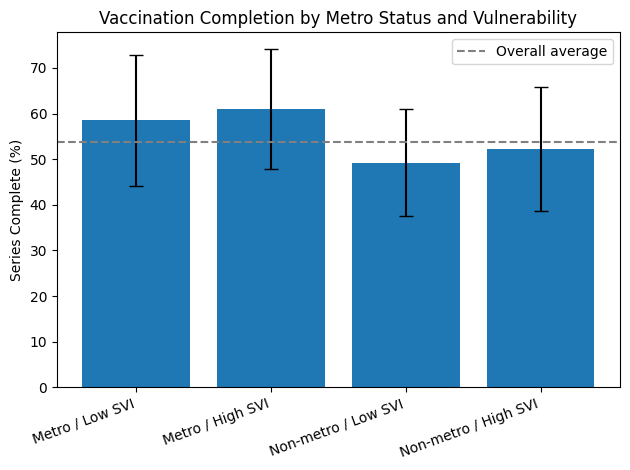

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("vaccination_minimal_filtered.csv", low_memory=False)
df["Date_parsed"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df_latest = df.sort_values("Date_parsed").groupby("FIPS", as_index=False).last()

# Define high vs low SVI (e.g., threshold at median of Series_Complete_Pop_Pct_SVI or use SVI_CTGY if available)
# Here assume Series_Complete_Pop_Pct_SVI is numeric proxy; lower implies higher vulnerability? adjust logic to data meaning.
median_svi = df_latest["Series_Complete_Pop_Pct_SVI"].median()
df_latest["SVI_group"] = np.where(df_latest["Series_Complete_Pop_Pct_SVI"] <= median_svi, "Low SVI", "High SVI")

# Create combined grouping
df_latest["group"] = df_latest["Metro_status"] + " / " + df_latest["SVI_group"]

summary = df_latest.groupby("group")["Series_Complete_Pop_Pct"].agg(["mean", "std"]).reindex([
    "Metro / Low SVI", "Metro / High SVI", "Non-metro / Low SVI", "Non-metro / High SVI"
])

# Plot
fig, ax = plt.subplots()
groups = summary.index
means = summary["mean"]
stds = summary["std"]
x = np.arange(len(groups))
ax.bar(x, means, yerr=stds, capsize=5)
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=20, ha="right")
ax.set_ylabel("Series Complete (%)")
ax.set_title("Vaccination Completion by Metro Status and Vulnerability")
ax.axhline(df_latest["Series_Complete_Pop_Pct"].mean(), color="gray", linestyle="--", label="Overall average")
ax.legend()
plt.tight_layout()
plt.savefig("white_hat_enhanced.png")
plt.show()


In [5]:
import pandas as pd
import numpy as np
import dash
from dash import dcc, html, Input, Output
import plotly.graph_objects as go

# Load and preprocess
df = pd.read_csv("vaccination_minimal_filtered.csv", low_memory=False)
df["Date_parsed"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df_latest = df.sort_values("Date_parsed").groupby("FIPS", as_index=False).last()

# Define high vs low SVI (adjust direction if needed)
median_svi = df_latest["Series_Complete_Pop_Pct_SVI"].median()
df_latest["SVI_group"] = np.where(
    df_latest["Series_Complete_Pop_Pct_SVI"] <= median_svi, "Low SVI", "High SVI"
)

app = dash.Dash(__name__)
app.layout = html.Div(style={"fontFamily": "Arial", "maxWidth": "900px", "margin": "auto"}, children=[
    html.H2("Ethical Visualization: COVID-19 Vaccination Disparities"),
    html.Div([
        html.Label("Mode:"),
        dcc.RadioItems(
            id="mode-toggle",
            options=[
                {"label": "White Hat (transparent)", "value": "white"},
                {"label": "Black Hat (obscured)", "value": "black"},
            ],
            value="white",
            inline=True,
            labelStyle={"marginRight": "20px"}
        ),
        html.Label("SVI filter:"),
        dcc.Dropdown(
            id="svi-filter",
            options=[
                {"label": "All", "value": "All"},
                {"label": "Low SVI", "value": "Low SVI"},
                {"label": "High SVI", "value": "High SVI"},
            ],
            value="All",
            clearable=False,
            style={"width": "220px", "display": "inline-block", "marginLeft": "10px"}
        )
    ], style={"marginBottom": "10px"}),
    dcc.Graph(id="main-plot", config={"displayModeBar": False}),
    html.Div(id="explanation", style={
        "marginTop": "10px", "padding": "10px", "border": "1px solid #ccc", "borderRadius": "5px"
    })
])

@app.callback(
    Output("main-plot", "figure"),
    Output("explanation", "children"),
    Input("mode-toggle", "value"),
    Input("svi-filter", "value"),
)
def update_plot(mode, svi_filter):
    # Apply SVI filter
    if svi_filter != "All":
        filtered = df_latest[df_latest["SVI_group"] == svi_filter].copy()
    else:
        filtered = df_latest.copy()

    if mode == "white":
        # White Hat: show subgroup distributions + uncertainty
        grouped = filtered.groupby("Metro_status")["Series_Complete_Pop_Pct"]
        means = grouped.mean()
        stds = grouped.std()

        fig = go.Figure()
        # Violin distributions per group
        for status in sorted(filtered["Metro_status"].dropna().unique()):
            subset = filtered[filtered["Metro_status"] == status]
            fig.add_trace(go.Violin(
                x=[status] * len(subset),
                y=subset["Series_Complete_Pop_Pct"],
                name=status,
                box_visible=True,
                meanline_visible=True,
                spanmode="hard",
                opacity=0.6
            ))
        # Mean ± SD overlay
        fig.add_trace(go.Bar(
            x=means.index,
            y=means.values,
            error_y=dict(type="data", array=stds.values, visible=True),
            name="Mean ± SD",
            marker=dict(color="black"),
            opacity=0.7
        ))

        fig.update_layout(
            title="White Hat: Vaccination Completion by Metro Status (with variability)",
            yaxis_title="Series Complete (%)",
            xaxis_title="Metro Status",
            legend_title="Legend",
            violingap=0.3,
            template="simple_white"
        )

        # Optional gap text if both groups exist
        expl = [html.P("Transparent view: subgroup breakdown, distributions, and uncertainty visible.")]
        if "Metro" in means.index and any(lbl != "Metro" for lbl in means.index):
            nonmetro = [lbl for lbl in means.index if lbl != "Metro"][0]
            gap = means["Metro"] - means[nonmetro]
            expl.insert(0, html.P(f"Insight: Metro counties are about {gap:.1f} percentage points higher than non-metro."))
        return fig, expl

    # Black Hat: aggregate to a single average and compress y-axis to downplay differences
        # Black Hat: single KPI framing + compressed scale + minimal cues
    overall = float(filtered["Series_Complete_Pop_Pct"].mean())

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=["All Counties"],
        y=[overall],
        marker=dict(color="#5B84B1", line=dict(width=0)),
        width=0.6,
        hovertemplate=f"Overall completion: {overall:.1f}%<extra></extra>"
    ))

    # Very tight band to minimize perceived variation
    pad = 1.5  # pp around the mean; feel free to reduce to 1.0 for even stronger effect
    fig.update_yaxes(
        range=[overall - pad, overall + pad],
        ticks="outside",
        ticklen=3,
        tickfont=dict(size=10),
        showgrid=False,
        title_text="Series Complete (%)"
    )

    # Clean, upbeat framing; no legend, no subgroup hints
    fig.update_layout(
        title="Black Hat: Vaccination Rates — Broad Consistency Across Regions",
        template="simple_white",
        showlegend=False,
        margin=dict(l=40, r=20, t=60, b=40)
    )

    # Big KPI-style label to anchor attention on the single number
    fig.add_annotation(
        x=0, y=overall,
        text=f"{overall:.1f}%",
        showarrow=False,
        yshift=18,
        font=dict(size=20, color="#2F3B4C")
    )

    expl = [
        html.P("Obscured view: single overall average presented as a KPI, compressed scale, no subgroup context or uncertainty."),
        html.P("Framing suggests broad consistency while the underlying metro and vulnerability gaps remain hidden.")
    ]
    return fig, expl


if __name__ == "__main__":
    app.run(debug=True)


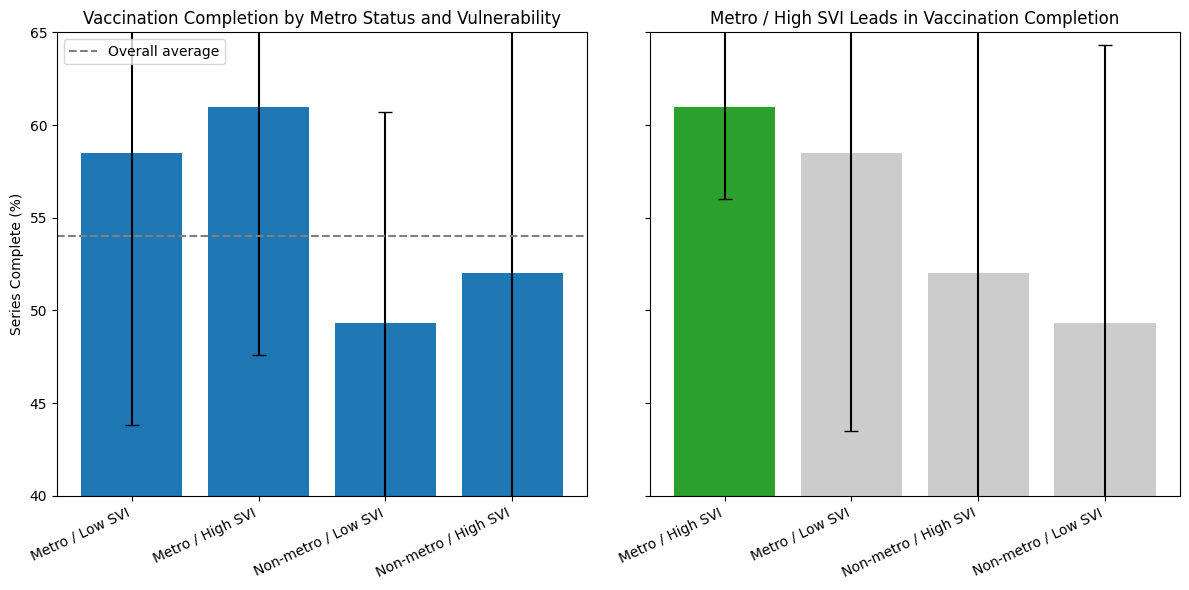

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the provided chart
categories = ["Metro / Low SVI", "Metro / High SVI", "Non-metro / Low SVI", "Non-metro / High SVI"]
values = [58.5, 61.0, 49.3, 52.0]
errors = [14.7, 13.4, 11.4, 14.6]
overall_avg = 54

x = np.arange(len(categories))

# --- WHITE HAT PLOT ---
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# White Hat: clean, accurate
ax[0].bar(x, values, yerr=errors, capsize=5, color="#1f77b4")
ax[0].axhline(overall_avg, color="gray", linestyle="--", label="Overall average")
ax[0].set_xticks(x)
ax[0].set_xticklabels(categories, rotation=25, ha="right")
ax[0].set_ylabel("Series Complete (%)")
ax[0].set_title("Vaccination Completion by Metro Status and Vulnerability")
ax[0].legend()

# --- BLACK HAT PLOT ---
# Manipulations:
# 1. Truncate y-axis to start at 40% to exaggerate differences
# 2. Reorder to emphasize largest bar first
# 3. Use green highlight for top bar
# 4. Misleading title framing
# 5. Reduce error bar on top bar, enlarge others slightly

black_values = [61.0, 58.5, 52.0, 49.3]
black_errors = [5, 15, 15, 15]  # smaller error for top bar
black_categories = ["Metro / High SVI", "Metro / Low SVI", "Non-metro / High SVI", "Non-metro / Low SVI"]

ax[1].bar(x, black_values, yerr=black_errors, capsize=5,
          color=["#2ca02c", "#cccccc", "#cccccc", "#cccccc"])
ax[1].set_xticks(x)
ax[1].set_xticklabels(black_categories, rotation=25, ha="right")
ax[1].set_ylim(40, 65)  # y-axis truncation
ax[1].set_title("Metro / High SVI Leads in Vaccination Completion")

plt.tight_layout()
plt.show()
